<a href="https://colab.research.google.com/github/glenbn/MLforHEP/blob/main/gethiggsdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Define path to your dataset stored in Google Drive
extracted_csv_gz_path = "/content/drive/MyDrive/MLforHEP/higgs.csv.gz"

# 2. Extract the ZIP file to disk (if the gzipped CSV is not already extracted)
if not os.path.exists(extracted_csv_gz_path):
    print(f"Extracting {extracted_csv_gz_path} from {extracted_csv_gz_path} archive...")
    # Unzip higgs.zip, which should contain HIGGS.csv.gz
    !unzip -q -o {extracted_csv_gz_path }
    print("Extraction complete!")
else:
    print(f"{extracted_csv_gz_path} already exists. Skipping extraction from {extracted_csv_gz_path}.")


# Define column names
columns = [
    'class_label',
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_b-tag',
    'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_b-tag',
    'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_b-tag',
    'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_b-tag',
    'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb'
]

# 3. Read directly from the unzipped CSV (Pandas handles .gz decompression)
print(f"Reading 100,000 rows from {extracted_csv_gz_path}...")
df = pd.read_csv(extracted_csv_gz_path, names=columns, nrows=100000)

print(f"Success! Data shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MLforHEP/higgs.csv.gz already exists. Skipping extraction from /content/drive/MyDrive/MLforHEP/higgs.csv.gz.
Reading 100,000 rows from /content/drive/MyDrive/MLforHEP/higgs.csv.gz...
Success! Data shape: (100000, 29)


In [ ]:
!ls -lh


total 8.0K
drwx------ 6 root root 4.0K Sep 28 02:45 drive
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data


In [ ]:
df.head()

,class_label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b-tag,...,jet_4_eta,jet_4_phi,jet_4_b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [ ]:
df.tail()

,class_label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b-tag,...,jet_4_eta,jet_4_phi,jet_4_b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
99995,0.0,1.541120,-0.948700,-0.762068,0.752259,-0.835360,0.554040,-0.258475,0.639910,1.086538,...,0.111138,0.049226,0.000000,0.359801,0.921513,0.977563,1.157282,0.971256,0.962689,0.914845
99996,1.0,0.957321,-0.759750,1.210569,0.863929,-0.120751,0.505580,0.058398,-0.496662,1.086538,...,1.127182,1.674563,0.000000,0.838526,0.731589,1.173853,0.848387,0.840251,0.702825,0.642653
99997,1.0,0.878993,-1.687942,-1.318039,0.407732,-1.481964,0.847367,-0.680313,1.462603,1.086538,...,-1.756052,-0.869814,0.000000,0.841216,1.112265,1.003257,0.768167,0.911731,0.911673,0.805071
99998,0.0,1.090185,0.409987,1.036898,0.427749,-1.035207,1.191169,-0.537720,1.576804,2.173076,...,0.301854,-0.435315,3.101961,0.986065,0.995841,0.989216,0.851650,1.313143,1.096304,0.963150
99999,1.0,1.395078,0.143119,-1.087772,0.581583,-0.127351,1.125120,-2.388460,1.306269,0.000000,...,1.423667,-0.208356,0.000000,0.804638,0.679799,0.983816,0.728147,1.098247,1.488028,1.466187


In [ ]:
df.dtypes

,0
class_label,float64
lepton_pT,float64
lepton_eta,float64
lepton_phi,float64
missing_energy_magnitude,float64
missing_energy_phi,float64
jet_1_pt,float64
jet_1_eta,float64
jet_1_phi,float64
jet_1_b-tag,float64


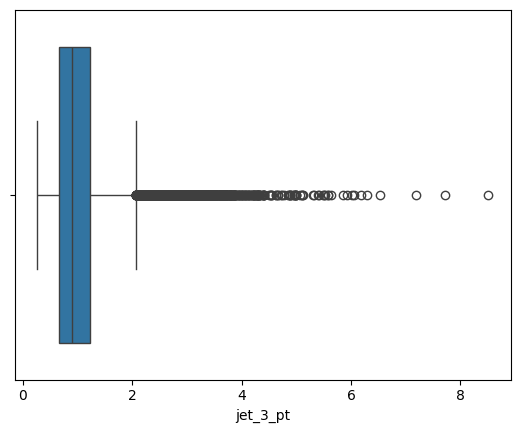

In [ ]:
import seaborn as sns
jet_3_pt_OutlierDetection = sns.boxplot(x=df["jet_3_pt"])